In [1]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from deep_isochron.model.latent_dynamics import (
    HopfLatentDynamics,
    HopfNormalForm,
)
from deep_isochron.systems.fitzhugh_nagumo import FitzhughNagumo
from einops import rearrange
from jaxtyping import Array, Float


jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("gpu")[1])


In [2]:
dyn = HopfLatentDynamics(dim=10, num_eig_comp=0, key=jax.random.key(0))
dyn.linear.eigenvalues

(Array([], shape=(0, 2), dtype=float64),
 Array([-1.29138111, -0.8631045 , -1.07735964, -1.30697225, -0.84435225,
        -0.88660562, -0.98987331, -0.86740485], dtype=float64))

In [3]:
ts = jnp.arange(0, 20.0, 0.01)
y0 = jax.random.uniform(jax.random.key(0), shape=(dyn.dim,))

In [4]:
out = dyn(ts, y0)

In [5]:
out.shape

(2000, 10)

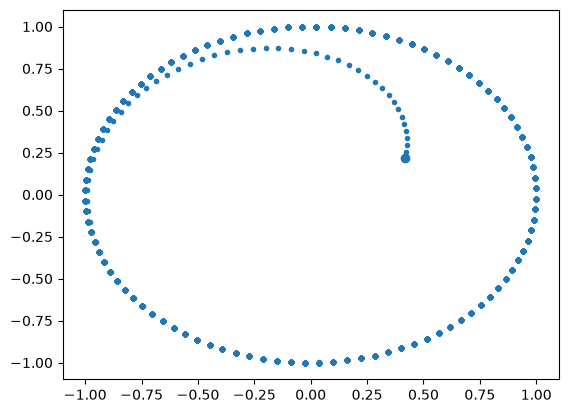

In [6]:
plt.plot(out[:, 0], out[:, 1], ".")
plt.scatter(y0[0], y0[1])

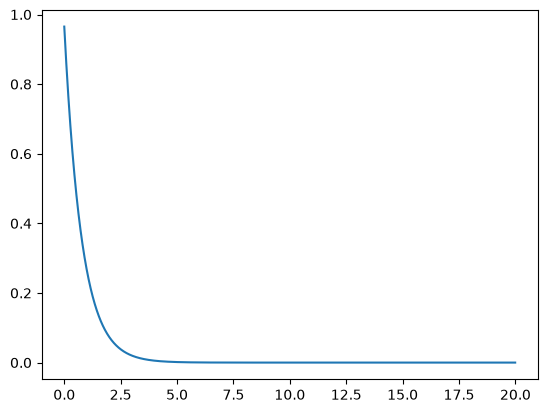

In [7]:
plt.plot(ts, out[:, 2])

In [8]:
rearrange(jnp.zeros(10), "(n d) -> n d", d=2).shape

(5, 2)

In [9]:
from deep_isochron.model.invertible import AbstractInvertibleTransform
from deep_isochron.model.latent_dynamics import AbstractLatentDynamics


class LatentDynamicsConverter(eqx.Module):
    latent_dynamics: AbstractLatentDynamics
    bijection: AbstractInvertibleTransform

    def __init__(
        self,
        latent_dynamics: AbstractLatentDynamics,
        bijection: AbstractInvertibleTransform,
    ):
        self.latent_dynamics = latent_dynamics
        self.bijection = bijection

    @property
    def dim(self) -> int:
        return self.latent_dynamics.dim

    def __call__(
        self,
        ts: Float[Array, " time"],
        x0: Float[Array, " obs_dim"],
        return_latent_trajectory: bool = True,
    ) -> tuple[Float[Array, "time obs_dim"], Float[Array, "time latent_dim"] | None]:
        y0: Float[Array, " latent_dim"] = self.bijection(x0)
        yt: Float[Array, "time latent_dim"] = self.latent_dynamics(ts, y0)
        xt: Float[Array, "time obs_dim"] = eqx.filter_vmap(self.bijection.inverse)(yt)

        if return_latent_trajectory:
            return xt, yt
        else:
            return xt, None


In [10]:
from deep_isochron.model.invertible import (
    InvertibleLinear,
    MonotonicRQCoupling,
    SequentialINN,
)


autoencoder = LatentDynamicsConverter(
    latent_dynamics=HopfNormalForm(),
    bijection=SequentialINN(
        [
            InvertibleLinear(dim=2, key=jax.random.key(0)),
            MonotonicRQCoupling(
                dim=2,
                width_hidden=32,
                num_knots=10,
                xy_range=(-4, 4),
                key=jax.random.key(1),
            ),
            InvertibleLinear(dim=2, key=jax.random.key(2)),
            MonotonicRQCoupling(
                dim=2,
                width_hidden=32,
                num_knots=10,
                xy_range=(-4, 4),
                key=jax.random.key(3),
            ),
            InvertibleLinear(dim=2, key=jax.random.key(4)),
            MonotonicRQCoupling(
                dim=2,
                width_hidden=32,
                num_knots=10,
                xy_range=(-4, 4),
                key=jax.random.key(5),
            ),
        ]
    ),
)

## Generate data for Fitahugh-Nagumo

In [11]:
ode = FitzhughNagumo()

u0 = jnp.asarray([1.0, 0.0])
t = jnp.linspace(0, 100, 1000)
sol = dfx.diffeqsolve(
    dfx.ODETerm(ode.rhs),
    dfx.Tsit5(),
    t[0],
    t[-1],
    None,
    u0,
    stepsize_controller=dfx.PIDController(rtol=1e-6, atol=1e-6),
    saveat=dfx.SaveAt(ts=t),
)

In [12]:
n_trajs = 1000
t = jnp.arange(0, 50 + 0.01, 0.01)


def solve_single(
    ode,
    ts: Float[Array, " time"],
    u0: Float[Array, " dim"],
    rtol: float = 1e-8,
    atol: float = 1e-10,
    solver: dfx.AbstractSolver = dfx.Tsit5(),
):
    sol: dfx.Solution = dfx.diffeqsolve(
        dfx.ODETerm(ode.rhs),
        solver,
        ts[0],
        ts[-1],
        None,
        u0,
        stepsize_controller=dfx.PIDController(rtol=rtol, atol=atol),
        saveat=dfx.SaveAt(ts=t),
    )
    return sol.ys


u0_train = jax.random.uniform(
    jax.random.key(0), (n_trajs, ode.dim), minval=-3, maxval=3
)
u_train = eqx.filter_vmap(solve_single, in_axes=(None, None, 0))(ode, t, u0_train)
print(u_train.shape)

(1000, 5001, 2)


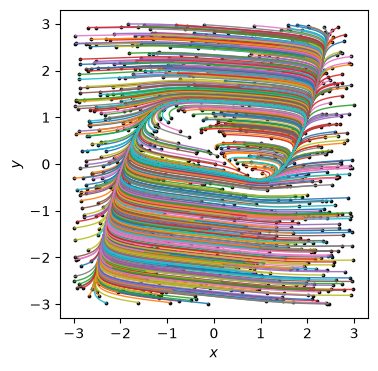

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i in range(0, len(u_train)):
    ax.plot(*u_train[i].T, alpha=0.9, linewidth=1.0)
ax.scatter(*u_train[:, 0].T, s=3, color="black", alpha=0.9)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_aspect("equal")

In [14]:
u_pred, y_pred = eqx.filter_vmap(autoencoder, in_axes=(None, 0))(t, u_train[:, 0])
u_pred.shape

(1000, 5001, 2)

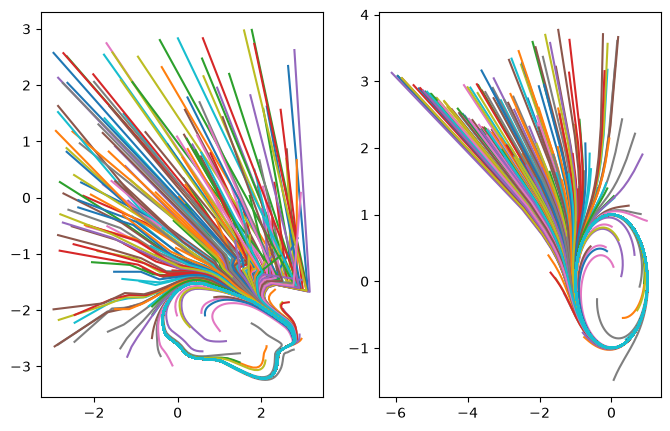

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
for i in range(0, len(u_pred), 5):
    axes[0].plot(*u_pred[i].T)
    axes[1].plot(*y_pred[i].T)

In [15]:
u_train_ae = eqx.filter_vmap(
    lambda x: autoencoder.bijection.inverse(autoencoder.bijection(x))
)(u_train[:, 0])
jnp.max(jnp.abs(u_train[:, 0] - u_train_ae))

Array(3.8191672e-14, dtype=float64)